###Introduction

In modern football analytics, expected goals (xG) has become a standard metric to evaluate the quality of scoring opportunities. However, not all players perform in line with their expected output — some consistently exceed expectations, while others underperform.

This project aims to identify and predict player overperformance, defined as scoring more goals than expected based on xG. Framing this as a binary classification problem allows us to explore whether player efficiency can be explained using measurable performance metrics.

Using a dataset of player statistics across top European leagues, we develop machine learning models to classify players as overperformers or non-overperformers. Special attention is given to handling class imbalance and selecting appropriate evaluation metrics.

The analysis progresses from exploratory data analysis (EDA) to model development and evaluation, concluding with feature importance interpretation to uncover the key drivers of player efficiency.

This project demonstrates how machine learning can be applied to sports analytics to generate actionable insights for scouting, player evaluation, and performance analysis.

In [23]:
# imports
import pandas as pd 
from pathlib import Path 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

In [24]:
# dataset
BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data"

df = pd.read_csv(DATA_DIR/"players.csv")
df.head()

,Squad,Comp,Player,Nation,Pos,Age,Born,MP,Minutes_Played,Mn_per_MP,...,Launch_percent_Passes_GK,AvgLen_Passes_GK,Att_Goal_Kicks_GK,AvgLen_GoalKick_GK,CrossesFaced_GK,CrossedStopped_GK,CrossedStopped_Perc_GK,OPA_Sweeper_GK,OPA_per_90_Sweeper_GK,AvgDist_Sweeper_GK
0,Ajaccio,Ligue 1,Mickaël Alphonse,GLP,DF,33,1989,26,1361.0,52.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ajaccio,Ligue 1,Cédric Avinel,GLP,DF,35,1986,24,1794.0,75.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ajaccio,Ligue 1,Mickaël Barreto,FRA,MF,31,1991,20,1325.0,66.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ajaccio,Ligue 1,Cyrille Bayala,BFA,MF,26,1996,33,2009.0,61.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Ajaccio,Ligue 1,Youcef Belaïli,ALG,"MF,FW",30,1992,17,1150.0,68.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
df.columns.tolist()

['Squad',
 'Comp',
 'Player',
 'Nation',
 'Pos',
 'Age',
 'Born',
 'MP',
 'Minutes_Played',
 'Mn_per_MP',
 'Mins_Per_90',
 'Starts',
 'PPM_Team.Success',
 'onG_Team.Success',
 'onGA_Team.Success',
 'plus_per__minus__Team.Success',
 'Goals',
 'Assists',
 'GoalsAssistsCombined',
 'NonPKG',
 'PK',
 'PKatt',
 'CrdY',
 'CrdR',
 'xG',
 'xAG',
 'npxG+xAG',
 'PrgC',
 'PrgP',
 'Gls_Per90',
 'Ast_Per90',
 'G+A_Per90',
 'G_minus_PK_Per',
 'G+A_minus_PK_Per',
 'xG_Per',
 'xAG_Per',
 'xG+xAG_Per',
 'Shots',
 'Shots_on_Target',
 'SoT_percent',
 'G_per_Sh',
 'G_per_SoT',
 'Avg_Shot_Dist',
 'FK_Standard',
 'G_minus_xG_Expected',
 'np:G_minus_xG_Expected',
 'Passes_Completed',
 'Passes_Attempted',
 'Passes_Cmp_percent',
 'PrgDist_Total',
 'Passes_Cmp_Short',
 'Passes_Att_Short',
 'Passes_Cmp_percent_Short',
 'Passes_Cmp_Medium',
 'Passes_Att_Medium',
 'Passes_Cmp_percent_Medium',
 'Passes_Cmp_Long',
 'Passes_Att_Long',
 'Passes_Cmp_percent_Long',
 'xA_Expected',
 'A_minus_xAG_Expected',
 'Key_Passes',


In [26]:
# create binary variable
df['overperform'] = (df['G_minus_xG_Expected'] > 0).astype(int)

df['overperform'].value_counts(normalize=True)

overperform
0    0.775701
1    0.224299
Name: proportion, dtype: float64

In [27]:
# clean features
features = [
    'Age',
    'Minutes_Played',
    'Shots',
    'Shots_on_Target',
    'SoT_percent',
    'Avg_Shot_Dist',
    'PrgC',
    'PrgP',
    'Key_Passes',
    'Passes_Completed',
    'Passes_Cmp_percent',
    'Miscontrolls',
    'Dispossessed']

In [28]:
# prepare dataset
df_model = df[features + ['overperform']].copy()

df_model = df_model.dropna()

In [29]:
# part df
X = df_model.drop('overperform', axis=1)
y = df_model['overperform']

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [30]:
# baseline model -logistic regression

model = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000))
])

model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [31]:
# evaluate
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.78      0.66      0.72       364
           1       0.49      0.63      0.55       185

    accuracy                           0.65       549
   macro avg       0.63      0.64      0.63       549
weighted avg       0.68      0.65      0.66       549



In [32]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.81      0.70      0.75       364
           1       0.53      0.68      0.60       185

    accuracy                           0.69       549
   macro avg       0.67      0.69      0.67       549
weighted avg       0.72      0.69      0.70       549



In [33]:
# feature importance
importances = rf_model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

feat_imp.head(10)

SoT_percent         0.259822
Shots_on_Target     0.155340
Shots               0.075739
Key_Passes          0.064186
Avg_Shot_Dist       0.063524
Minutes_Played      0.062149
PrgC                0.051843
Miscontrolls        0.049493
Passes_Completed    0.048217
Dispossessed        0.048158
dtype: float64

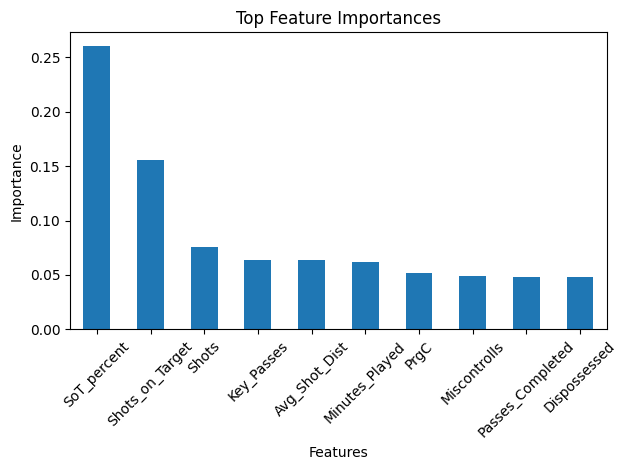

In [34]:
# graph
feat_imp.head(10).plot(kind='bar')

plt.title("Top Feature Importances")
plt.ylabel("Importance")
plt.xlabel("Features")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../images/feature_importance.png")

plt.show()

### Conclusion

This project explored the ability to predict player overperformance relative to expected goals (xG) using a binary classification approach.

The dataset presented a class imbalance, with approximately 22% of players classified as overperformers. To address this, models were evaluated with a focus on recall, prioritizing the identification of high-performing players.

A Logistic Regression model was used as a baseline, achieving moderate performance. A Random Forest model significantly improved results, increasing recall for overperforming players while also improving precision and overall accuracy.

Feature importance analysis revealed that **shooting efficiency (SoT%) is the strongest predictor of overperformance**, followed by shot volume metrics such as shots on target and total shots. This suggests that finishing quality plays a more critical role than opportunity volume alone.

Overall, the model demostrates that player overperformance can be partially explained through measurable performance metrics, offering potential applications in scouting, player evaluation and performance analysis.